# Zachary's Karate Club Network

Load NetworkX's built-in Karate Club graph, visualize it, and summarize its size and highest-degree nodes.

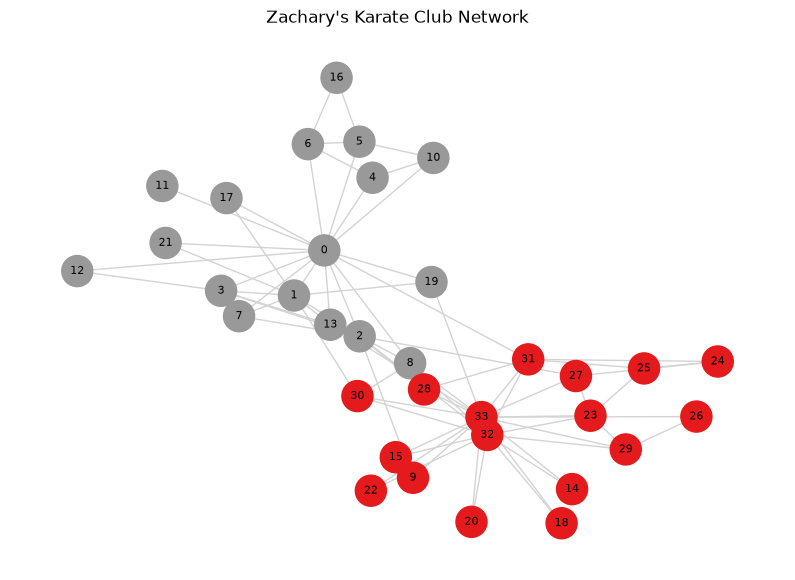

Number of nodes: 34
Number of edges: 78
Five highest-degree nodes:
Node 12 data: {'club': 'Mr. Hi'}
Degree of node 12: 2
Neighbors of node 12: [0, 3]
Position of node 12: [-0.63157737  0.24946302]


In [5]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.karate_club_graph()

plt.figure(figsize=(10, 7))
position = nx.spring_layout(G, seed=42)
nx.draw_networkx(
    G,
    pos=position,
    node_color=[G.nodes[node]["club"] == "Mr. Hi" for node in G],
    cmap=plt.cm.Set1,
    with_labels=True,
    node_size=500,
    font_size=8,
    edge_color="lightgray",
)
plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()

highest_degree_nodes = sorted(G.degree, key=lambda item: (-item[1], item[0]))[:5]

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print("Five highest-degree nodes:")
print(f"Node 12 data: {G.nodes[12]}")
print(f"Degree of node 12: {G.degree[12]}")
print(f"Neighbors of node 12: {list(G.neighbors(12))}")
print(f"Position of node 12: {position[12]}")

In [6]:
import pandas as pd

# Enter your own node IDs as a comma-separated list, e.g. "0,1,2,12,33"
node_input = input("Enter node IDs separated by commas: ")

if node_input.strip():
    selected_nodes = [int(n.strip()) for n in node_input.split(",") if n.strip()]
else:
    selected_nodes = [node for node, _ in highest_degree_nodes]

# Build adjacency matrix for only those nodes
adj_matrix = nx.to_numpy_array(G, nodelist=selected_nodes, dtype=int)

# Convert to a DataFrame for easy viewing
adj_df = pd.DataFrame(adj_matrix, index=selected_nodes, columns=selected_nodes)

print("Selected nodes:", selected_nodes)
display(adj_df)

Selected nodes: [33, 0, 32, 2, 1]


,33,0,32,2,1
33,0,0,5,0,0
0,0,0,0,5,4
32,5,0,0,2,0
2,0,5,2,0,6
1,0,4,0,6,0
